# Person 4: best-practices perturbation analysis

This notebook asks: **which perturbations affect which biological endpoints, how large are the effects, and at what stage of the dynamics do they act?**

The analysis does not rely on a single phase diagram. It combines:

1. global parameter–endpoint associations
2. nonlinear binned response curves
3. standardized regression and interaction terms
4. endpoint tradeoff plots
5. representative ODE time courses
6. explicit treatment of nonconvergence and collapse

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from dataclasses import replace
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from ma2024_model import DEFAULT_PARAMS
from sweep_engine import simulate_logspace

sns.set_theme(style='whitegrid', context='notebook')
df = pd.read_csv('treatment_grid.csv')
PARAMS = ['kappa_b', 'd_a', 'phi_max', 'xi']
LABELS = {'kappa_b':'κ_b', 'd_a':'d_a', 'phi_max':'φ_max', 'xi':'ξ'}
BASELINE = {'kappa_b':0.35, 'd_a':0.02, 'phi_max':1.0, 'xi':0.8}

# Derived biological quantities
df['total_final'] = df['ns_final'] + df['nr_final']
df['total_initial'] = 0.4
df['community_ratio_R_to_S'] = df['nr_final'] / df['ns_final'].replace(0, np.nan)
df['nonconverged'] = ~df['ss_converged']
df['collapsed'] = df['total_final'] < 1e-6

OUTCOMES = ['diversity_final','t_steady_state','f_R_final','t_recovery_S','peak_loss_total','total_final','ns_final','nr_final']
OUTCOME_LABELS = {'diversity_final':'Final diversity','t_steady_state':'Steady-state time','f_R_final':'Final resistant fraction','t_recovery_S':'S recovery time','peak_loss_total':'Peak total loss','total_final':'Final total population','ns_final':'Final S population','nr_final':'Final R population'}
print(df.shape)
print('Nonconverged:', df['nonconverged'].sum())
print('Collapsed:', df['collapsed'].sum())

(194481, 21)
Nonconverged: 462
Collapsed: 282


# Functions

In [3]:
def binned_effect_plot(outcome, n_bins=11):
    """
    Purpose:
        Visualize the global marginal effect of each parameter on one
        selected model endpoint. Parameter values are divided into bins,
        and the mean endpoint value is plotted for each bin.

    Inputs:
        outcome : str
            Name of the dataframe column containing the endpoint to plot.

        n_bins : int, optional
            Number of bins used to group each parameter's values.
            Default is 11.

    Outputs:
        fig : matplotlib.figure.Figure
            Figure containing one subplot for each parameter.

    Notes:
        The shaded region represents ±1 standard deviation around the
        mean endpoint value within each parameter bin.
    """

    fig, axes = plt.subplots(1, 4, figsize=(19, 4.5), constrained_layout=True)

    for ax, parameter in zip(axes, PARAMS):
        temp = df[[parameter, outcome]].copy()
        temp["bin"] = pd.qcut(temp[parameter], q=n_bins, duplicates="drop")
        summary = temp.groupby("bin", observed=True).agg(x=(parameter, "mean"), mean=(outcome, "mean"), sd=(outcome, "std"), n=(outcome, "size")).reset_index()
        ax.plot(summary["x"], summary["mean"], marker="o", color="#0072B2")
        ax.fill_between(summary["x"], summary["mean"] - summary["sd"], summary["mean"] + summary["sd"], alpha=0.2, color="#0072B2")
        ax.set_xlabel(LABELS[parameter])
        ax.set_ylabel(OUTCOME_LABELS.get(outcome, outcome))
        ax.set_title(LABELS[parameter])
        ax.grid(alpha=0.2)

    fig.suptitle(f"Global marginal effect on {OUTCOME_LABELS.get(outcome, outcome)}", fontsize=15)

    return fig

In [4]:
def standardized_formula(outcome):
    """
    Purpose:
        Fit a linear regression model using standardized parameters and
        a standardized endpoint so that parameter effects can be compared
        on the same scale.

    Inputs:
        outcome : str
            Name of the dataframe column containing the endpoint to model.

    Outputs:
        model : statsmodels.regression.linear_model.RegressionResultsWrapper
            Fitted standardized ordinary least-squares regression model.

    Notes:
        Each parameter and the selected outcome are converted to z-scores
        by subtracting their mean and dividing by their standard deviation.
        The resulting coefficients show the relative effect size of each
        parameter on the selected outcome.
    """

    z = df.copy()  # Create a copy so the original dataframe is not modified.

    for p in PARAMS + [outcome]:  # Standardize every parameter and the selected outcome.
        z[p] = (z[p] - z[p].mean()) / z[p].std()  # Convert the column to a z-score.

    formula = outcome + " ~ " + " + ".join(PARAMS)  # Build the regression formula.

    model = smf.ols(formula, data=z).fit()  # Fit the standardized ordinary least-squares model.

    return model  # Return the fitted regression model.

In [5]:
def representative_values(parameter):
    """
    Purpose:
        Select the lowest, baseline, and highest values of a parameter
        for representative time-course simulations.

    Inputs:
        parameter : str
            Name of the parameter column in the dataframe.

    Outputs:
        list
            Three parameter values: minimum, baseline-nearest, and maximum.
    """

    values = np.sort(df[parameter].unique())  # Get sorted unique parameter values.

    return [values[0], values[np.argmin(abs(values - BASELINE[parameter]))], values[-1]]  # Return low, baseline, and high values.


def timecourse_panel(parameter, t_end=60):
    """
    Purpose:
        Plot how antibiotic concentration, sensitive-cell density, and
        resistant-cell density change over time as one parameter varies.

    Inputs:
        parameter : str
            Name of the parameter being varied.

        t_end : int or float, optional
            Final simulation time. Default is 60.

    Outputs:
        fig : matplotlib.figure.Figure
            Figure containing three time-course subplots.

    Notes:
        All non-varied parameters remain at their default values.
        The three curves represent the minimum, baseline-nearest, and
        maximum values of the selected parameter.
    """

    values = representative_values(parameter)  # Select low, baseline, and high parameter values.

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharex=True)  # Create three linked subplots.

    for value in values:  # Run one simulation for each representative value.
        p = replace(DEFAULT_PARAMS, **{parameter: float(value)})  # Replace only the selected parameter.

        sol = simulate_logspace(p, a0=2.15, i_dose=10, t_span=(0, t_end), n_points=500)  # Simulate the ODE system.

        label = f"{LABELS[parameter]}={value:g}"  # Create the curve label.

        axes[0].plot(sol.t, sol.a, label=label)  # Plot antibiotic concentration over time.
        axes[1].plot(sol.t, sol.ns, label=label)  # Plot sensitive-cell density over time.
        axes[2].plot(sol.t, sol.nr, label=label)  # Plot resistant-cell density over time.

    for ax, title, ylabel in zip(axes, ["Antibiotic", "Sensitive population", "Resistant population"], ["a", "n_s", "n_r"]):  # Format each subplot.
        ax.set_title(title)  # Add the subplot title.
        ax.set_xlabel("Time")  # Label the x-axis.
        ax.set_ylabel(ylabel)  # Label the y-axis.
        ax.grid(alpha=0.2)  # Add a light grid.

    axes[-1].legend(fontsize=8)  # Display the parameter-value legend on the final subplot.

    fig.suptitle(f"Dynamics as {LABELS[parameter]} changes; other parameters at baseline")  # Add the overall title.

    plt.tight_layout()  # Adjust subplot spacing.

    return fig  # Return the completed figure.

In [6]:
from matplotlib.lines import Line2D


def plot_population_composition_vs_parameter(parameter, n_bins=11):
    """
    Purpose:
        Show how final sensitive and resistant population densities and
        community fractions change as one parameter increases.

    Inputs:
        parameter : str
            Name of the parameter column being analyzed.

        n_bins : int, optional
            Number of quantile-based parameter bins used to summarize the
            global trend. Default is 11.

    Outputs:
        fig : matplotlib.figure.Figure
            Figure containing absolute population and population-fraction plots.

        axes : numpy.ndarray
            Array containing the two subplot axes.

    Notes:
        The shaded regions represent ±1 standard deviation around the
        mean value within each parameter bin.
    """

    temp = df.copy()  # Create a copy so the original dataframe is not modified.

    temp["S_fraction_final"] = temp["ns_final"] / (temp["ns_final"] + temp["nr_final"]).replace(0, np.nan)  # Calculate the final sensitive fraction.
    temp["R_fraction_final"] = temp["nr_final"] / (temp["ns_final"] + temp["nr_final"]).replace(0, np.nan)  # Calculate the final resistant fraction.
    temp["parameter_bin"] = pd.qcut(temp[parameter], q=n_bins, duplicates="drop")  # Divide parameter values into quantile-based bins.

    summary = temp.groupby("parameter_bin", observed=True).agg(parameter_value=(parameter, "mean"), ns_mean=("ns_final", "mean"), ns_sd=("ns_final", "std"), nr_mean=("nr_final", "mean"), nr_sd=("nr_final", "std"), S_fraction_mean=("S_fraction_final", "mean"), S_fraction_sd=("S_fraction_final", "std"), R_fraction_mean=("R_fraction_final", "mean"), R_fraction_sd=("R_fraction_final", "std")).reset_index()  # Calculate means and standard deviations within each bin.

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)  # Create absolute-population and fraction subplots.
    ax = axes[0]  # Select the absolute-population subplot.
    ax.plot(summary["parameter_value"], summary["ns_mean"], color="tab:green", marker="o", label="Sensitive population, n_s")  # Plot the mean sensitive population.
    ax.fill_between(summary["parameter_value"], summary["ns_mean"] - summary["ns_sd"], summary["ns_mean"] + summary["ns_sd"], color="tab:green", alpha=0.2)  # Show ±1 standard deviation for sensitive cells.
    ax.plot(summary["parameter_value"], summary["nr_mean"], color="tab:gray", marker="o", label="Resistant population, n_r")  # Plot the mean resistant population.
    ax.fill_between(summary["parameter_value"], summary["nr_mean"] - summary["nr_sd"], summary["nr_mean"] + summary["nr_sd"], color="tab:gray", alpha=0.2)  # Show ±1 standard deviation for resistant cells.
    ax.set_xlabel(LABELS[parameter])  # Label the parameter axis.
    ax.set_ylabel("Final population density")  # Label the population axis.
    ax.set_title("Absolute final populations")  # Add the subplot title.
    ax.legend()  # Display the population legend.
    ax.grid(alpha=0.2)  # Add a light grid.

    ax = axes[1]  # Select the population-fraction subplot.

    ax.plot(summary["parameter_value"], summary["S_fraction_mean"], color="tab:green", marker="o", label="Sensitive fraction")  # Plot the mean sensitive fraction.
    ax.fill_between(summary["parameter_value"], summary["S_fraction_mean"] - summary["S_fraction_sd"], summary["S_fraction_mean"] + summary["S_fraction_sd"], color="tab:green", alpha=0.2)  # Show ±1 standard deviation for sensitive fractions.
    ax.plot(summary["parameter_value"], summary["R_fraction_mean"], color="tab:gray", marker="o", label="Resistant fraction")  # Plot the mean resistant fraction.
    ax.fill_between(summary["parameter_value"], summary["R_fraction_mean"] - summary["R_fraction_sd"], summary["R_fraction_mean"] + summary["R_fraction_sd"], color="tab:gray", alpha=0.2)  # Show ±1 standard deviation for resistant fractions.
    ax.set_xlabel(LABELS[parameter])  # Label the parameter axis.
    ax.set_ylabel("Fraction of final community")  # Label the fraction axis.
    ax.set_ylim(0, 1)  # Restrict fractions to the range from 0 to 1.
    ax.set_title("Final population fractions")  # Add the subplot title.
    ax.legend()  # Display the fraction legend.
    ax.grid(alpha=0.2)  # Add a light grid.

    fig.suptitle(f"Community composition as {LABELS[parameter]} increases", fontsize=15)  # Add the overall figure title.

    return fig, axes  # Return the figure and subplot axes.

In [12]:
from dataclasses import replace
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def clearance_recovery_plot(t_end=60, antibiotic_threshold=0.1):
    """
    Purpose:
        Compare antibiotic clearance, total population recovery, and
        sensitive/resistant community composition as each parameter varies.

    Inputs:
        t_end : int or float, optional
            Final simulation time. Default is 60.

        antibiotic_threshold : float, optional
            Antibiotic concentration used to define the clearance time.
            Default is 0.1.

    Outputs:
        clearance_summary : pandas.DataFrame
            Table containing clearance time, antibiotic exposure, minimum
            population, final population, and final community fractions for
            each parameter and selected parameter level.

    Notes:
        The figure contains one row for each parameter and three columns:
        antibiotic concentration, total population density, and community
        composition. Each parameter is simulated at its lowest, middle, and
        highest values. Sensitive cells are shown in light blue and resistant
        cells are shown in pale red.
    """

    fig, axes = plt.subplots(len(PARAMS), 3, figsize=(20, 17), sharex=True, constrained_layout=True)  # Create the subplot grid.
    clearance_summary = []  # Store summary metrics from each simulation.
    colors = ["#0072B2", "#E69F00", "#D55E00"]  # Define low, middle, and high parameter curve colors.
    sensitive_color = "#BFD7EA"  # Define the light-blue sensitive fraction color.
    resistant_color = "#F4B6B6"  # Define the pale-red resistant fraction color.

    for row, parameter in enumerate(PARAMS):  # Analyze each parameter separately.
        values = np.sort(df[parameter].unique())  # Get sorted unique values for the parameter.
        selected_values = [values[0], values[len(values) // 2], values[-1]]  # Select the lowest, middle, and highest values.
        levels = ["low", "middle", "high"]  # Label the selected parameter levels.

        row_handles = []  # Store legend handles for the parameter values.

        for value, level, color in zip(selected_values, levels, colors):  # Run one simulation for each selected parameter value.
            p = replace(DEFAULT_PARAMS, **{parameter: float(value)})  # Change only the selected parameter.
            sol = simulate_logspace(p, a0=2.15, i_dose=10, t_span=(0, t_end), n_points=600)  # Simulate the ODE system.
            
            total_population = sol.ns + sol.nr  # Calculate the total population density.
            sensitive_fraction = np.divide(sol.ns, total_population, out=np.zeros_like(total_population), where=total_population > 0)  # Calculate the sensitive population fraction.
            resistant_fraction = np.divide(sol.nr, total_population, out=np.zeros_like(total_population), where=total_population > 0)  # Calculate the resistant population fraction.

            below_threshold = np.where(sol.a <= antibiotic_threshold)[0]  # Identify times when antibiotic is below the clearance threshold.

            clearance_time = sol.t[below_threshold[0]] if len(below_threshold) > 0 else np.nan  # Record the first clearance time.
            antibiotic_exposure = np.trapz(sol.a, sol.t)  # Calculate total antibiotic exposure over time.
            clearance_summary.append({"parameter": parameter, "level": level, "value": value, "clearance_time": clearance_time, "antibiotic_AUC": antibiotic_exposure, "minimum_total_population": total_population.min(), "final_total_population": total_population[-1], "final_sensitive_fraction": sensitive_fraction[-1], "final_resistant_fraction": resistant_fraction[-1]})  # Save summary metrics.

            label = f"{level.capitalize()}: {LABELS[parameter]} = {value:g}"  # Create the parameter-value legend label.

            row_handles.append(Line2D([0], [0], color=color, linewidth=2.5, label=label))  # Create a legend handle for the parameter value.

            ax = axes[row, 0]  # Select the antibiotic subplot.
            ax.plot(sol.t, sol.a, color=color, linewidth=2.2)  # Plot antibiotic concentration over time.
            ax.axhline(antibiotic_threshold, color="black", linestyle="--", linewidth=1.2, alpha=0.7)  # Show the antibiotic clearance threshold.
            ax = axes[row, 1]  # Select the total-population subplot.
            ax.plot(sol.t, total_population, color=color, linewidth=2.2)  # Plot total population over time.
            ax = axes[row, 2]  # Select the community-composition subplot.

            if level == "low":  # Use the low-value simulation to show the filled composition areas.
                ax.stackplot(sol.t, sensitive_fraction, resistant_fraction, colors=[sensitive_color, resistant_color], alpha=0.85)  # Show sensitive and resistant fractions as colored areas.

            else:  # Overlay middle and high parameter composition boundaries.
                ax.plot(sol.t, sensitive_fraction, color=color, linewidth=1.8, linestyle="-")  # Show the sensitive fraction boundary.
                ax.plot(sol.t, resistant_fraction, color=color, linewidth=1.8, linestyle="--")  # Show the resistant fraction boundary.

        axes[row, 0].legend(handles=row_handles, title=f"Perturbed {LABELS[parameter]}", fontsize=8, title_fontsize=9, loc="upper left", bbox_to_anchor=(0.02, 0.98))  # Place the parameter legend only on the left subplot to prevent overlap.
        axes[row, 0].set_ylabel(f"{LABELS[parameter]}\nAntibiotic concentration, a\n(dimensionless)")  # Label the antibiotic axis.
        axes[row, 1].set_ylabel("Total population density\n(dimensionless)")  # Label the total-population axis.
        axes[row, 2].set_ylabel("Community fraction\n(0–1)")  # Label the composition axis.
        axes[row, 2].set_ylim(0, 1)  # Restrict community fractions to the range from 0 to 1.

        for ax in axes[row, :]:  # Format every subplot in the current row.
            ax.grid(alpha=0.2)  # Add a light grid.

    axes[0, 0].set_title("Antibiotic clearance", fontsize=13)  # Add the first column title.
    axes[0, 1].set_title("Population crash and recovery", fontsize=13)  # Add the second column title.
    axes[0, 2].set_title("Community composition", fontsize=13)  # Add the third column title.

    for ax in axes[-1, :]:  # Format the bottom-row x-axes.
        ax.set_xlabel("Time, τ (dimensionless)")  # Label the time axis.

    composition_handles = [Patch(facecolor=sensitive_color, label="Sensitive fraction"), Patch(facecolor=resistant_color, label="Resistant fraction"), Line2D([0], [0], color="black", linestyle="--", label=f"Antibiotic threshold = {antibiotic_threshold:g}")]  # Create the composition legend handles.
    axes[-1, 2].legend(handles=composition_handles, title="Composition and threshold", fontsize=8, title_fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1.0))  # Place the composition legend outside the final subplot.
    fig.suptitle("Antibiotic clearance, population recovery, and community composition", fontsize=18, y=1.02)  # Add the overall figure title.
    plt.show()  # Display the figure.

    return pd.DataFrame(clearance_summary)  # Return the summary table.

# Figures

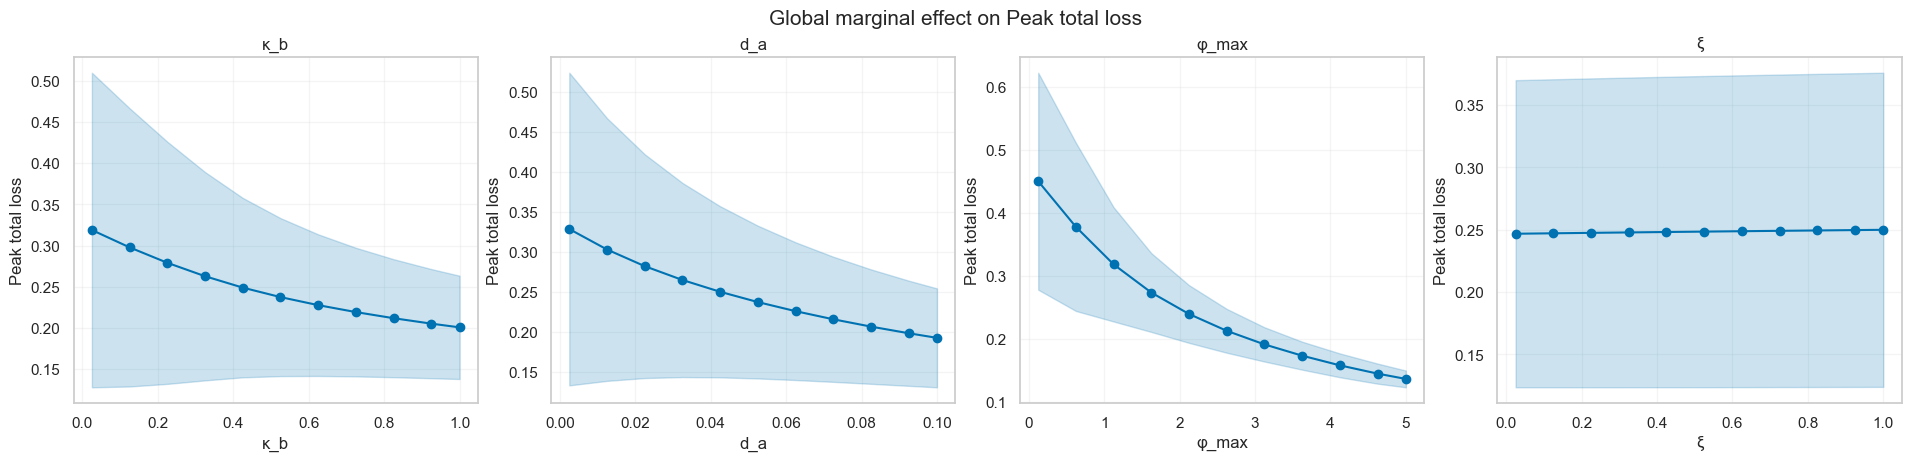

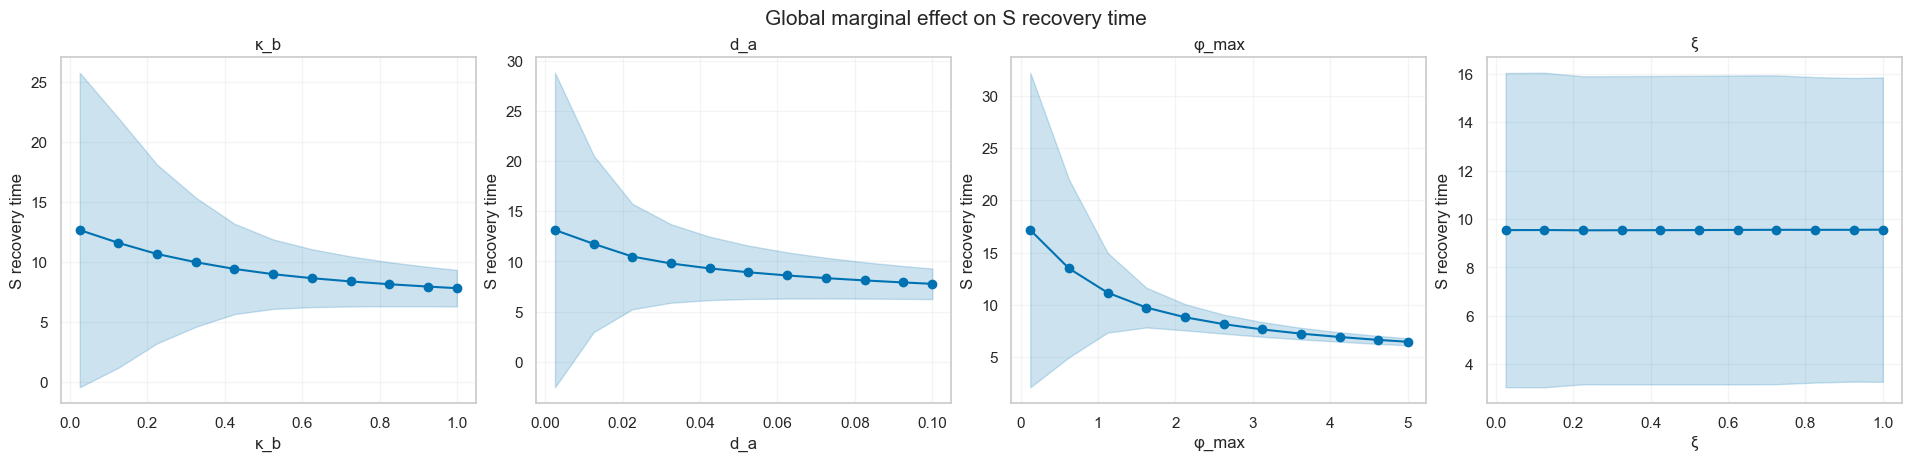

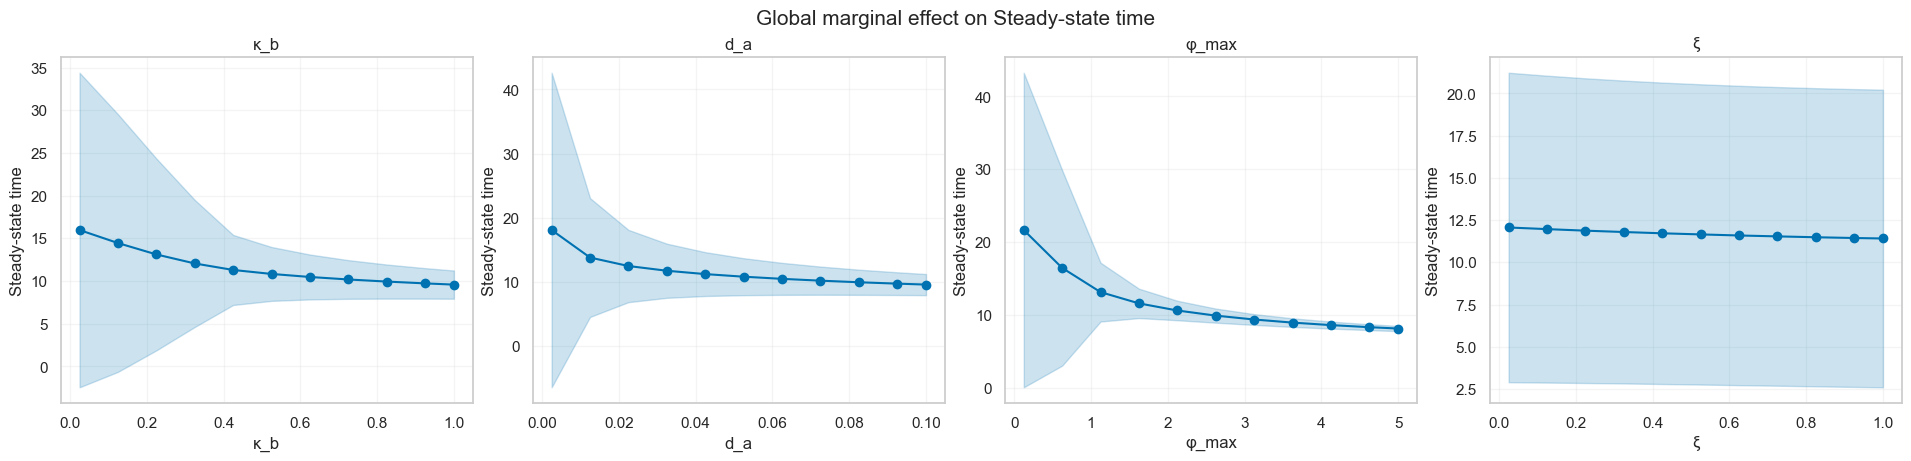

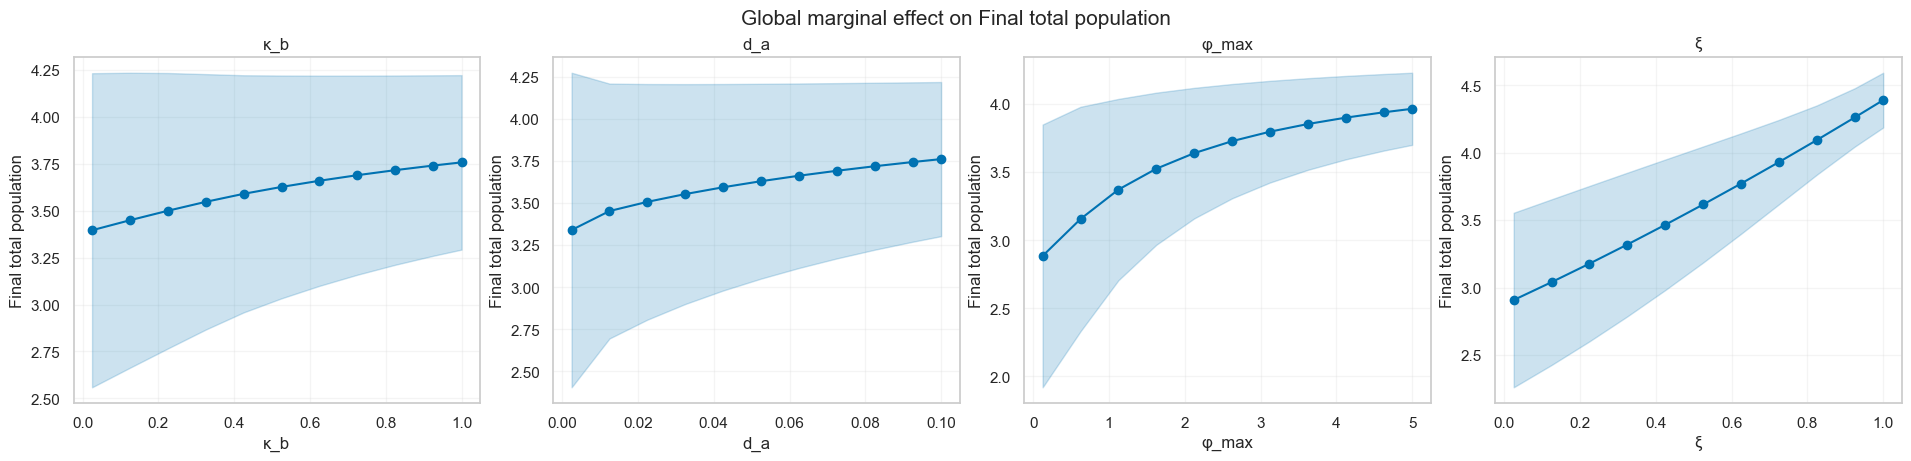

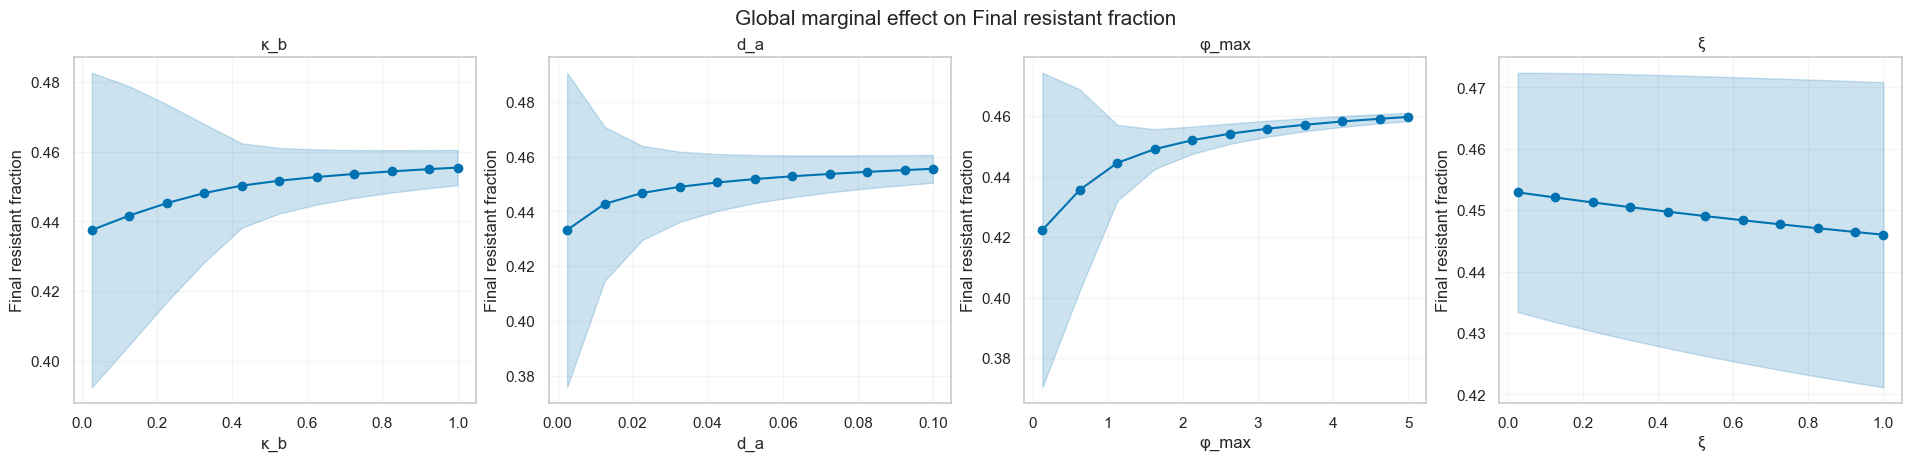

In [8]:
for outcome in ['peak_loss_total','t_recovery_S','t_steady_state','total_final','f_R_final']:
    binned_effect_plot(outcome); plt.show()

**Description:**  
This figure summarizes how κ_b, d_a, φ_max, and ξ affect several treatment outcomes. Each row shows a different endpoint: peak population loss, sensitive-cell recovery time, time to steady state, final total population, and final resistant fraction. Within each row, the four panels show how the endpoint changes as one parameter increases. The line represents the mean across simulations, while the shaded region shows variability from the other parameters.

**Interpretation:**  
φ_max has the strongest overall effect. Increasing φ_max reduces population loss, speeds sensitive-cell recovery and steady-state convergence, increases final population size, and slightly increases the final resistant fraction. κ_b and d_a have similar but weaker effects: they improve antibiotic clearance and recovery while modestly increasing final population size and resistant fraction. ξ has little effect on crash severity, recovery time, or steady-state time, but it substantially increases final population size. This suggests that nutrient recycling mainly supports post-treatment regrowth, whereas the antibiotic-degradation parameters primarily control antibiotic clearance and recovery.

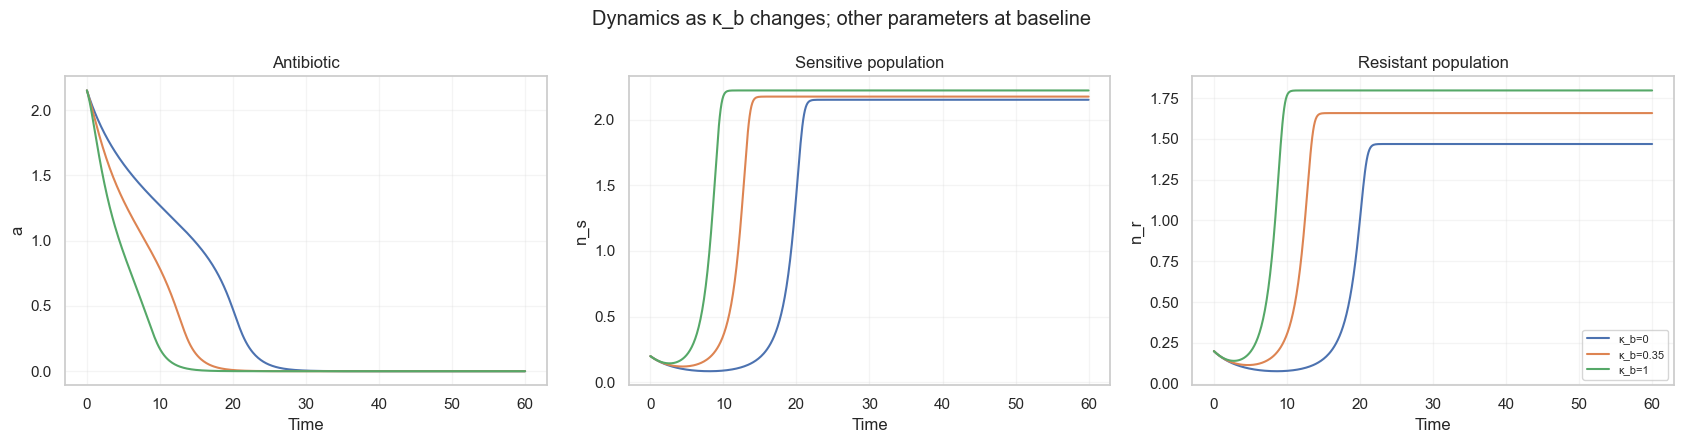

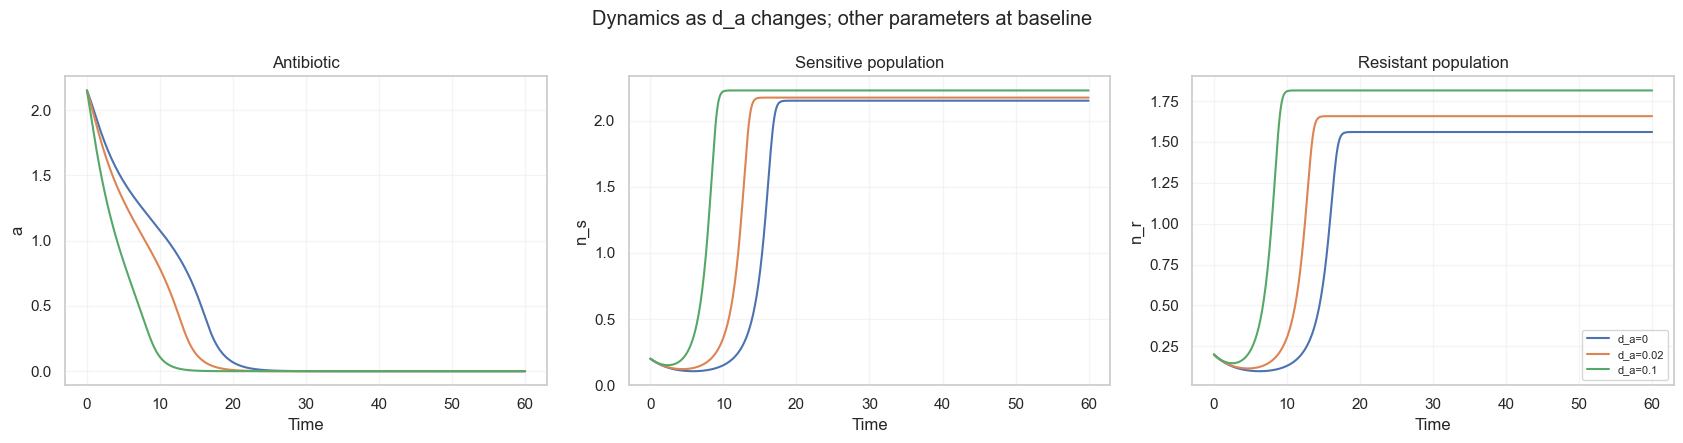

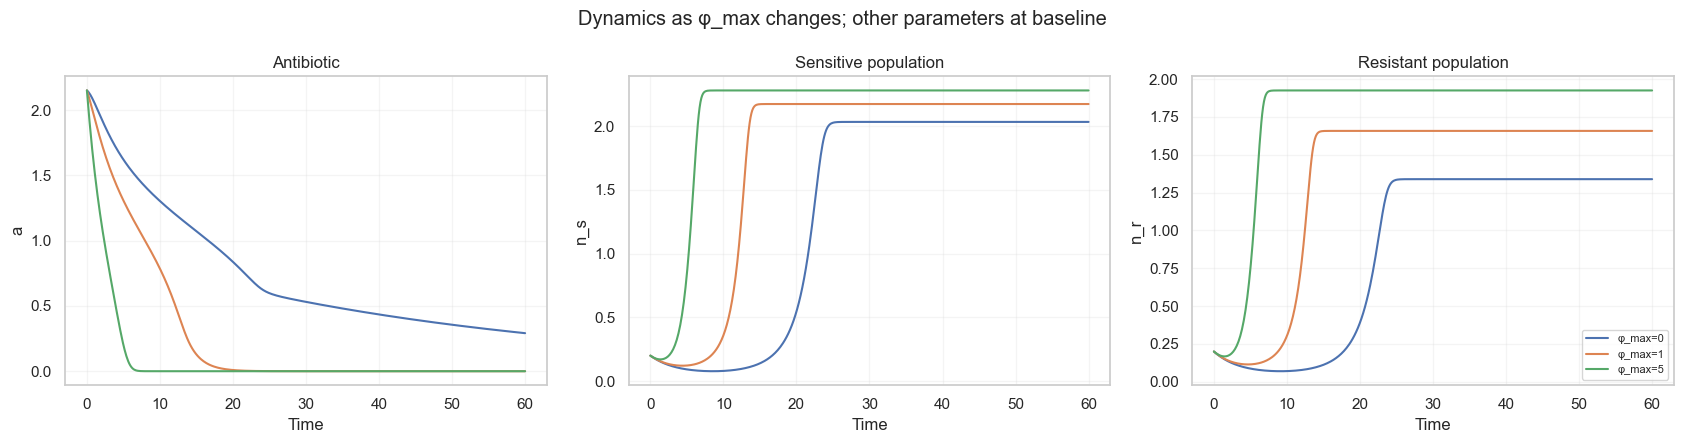

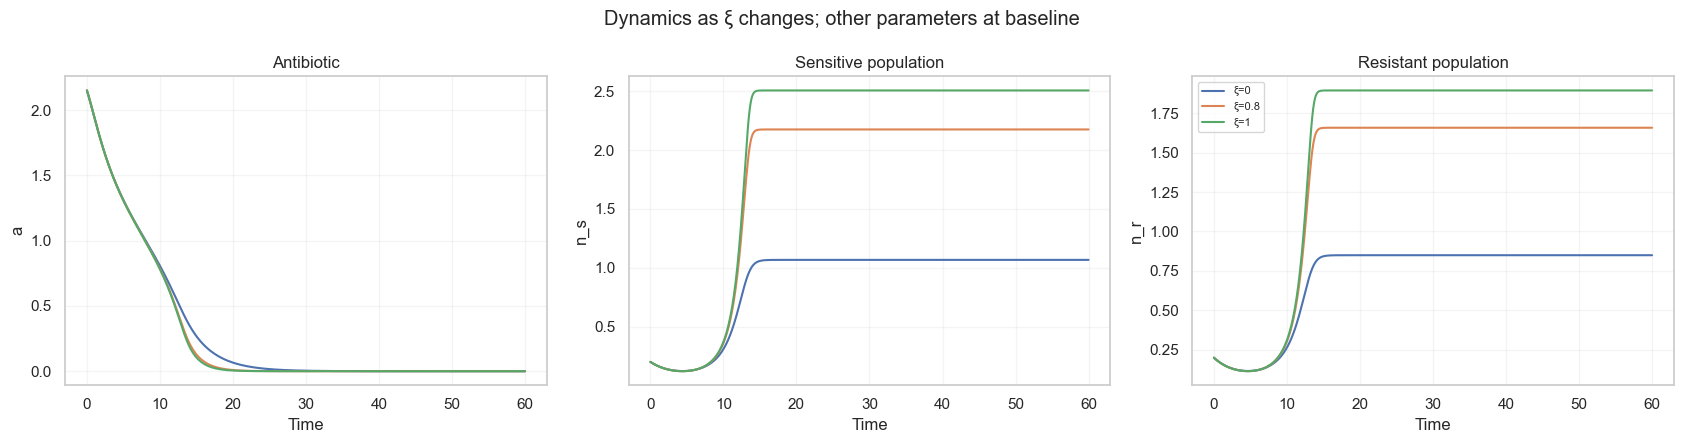

In [9]:
for parameter in PARAMS:
    timecourse_panel(parameter); plt.show()

**Description:**  
This figure shows how the antibiotic concentration, sensitive population, and resistant population change over time when each parameter is varied individually. Each row represents one parameter, with low, baseline, and high values shown by separate colored curves. The other parameters are held at their baseline values.

**Interpretation:**  
Increasing κ_b, d_a, and φ_max causes the antibiotic to clear more quickly, allowing both sensitive and resistant populations to recover earlier. The effect is strongest for φ_max: when resistant-cell degradation is low, antibiotic persists much longer and population recovery is delayed, whereas high φ_max produces rapid clearance and recovery. ξ has little effect on antibiotic clearance because it controls nutrient recycling rather than antibiotic removal. Instead, increasing ξ mainly increases the final sizes of both populations after recovery. Overall, κ_b, d_a, and φ_max primarily control antibiotic clearance and recovery timing, while ξ mainly controls the amount of post-treatment population regrowth.

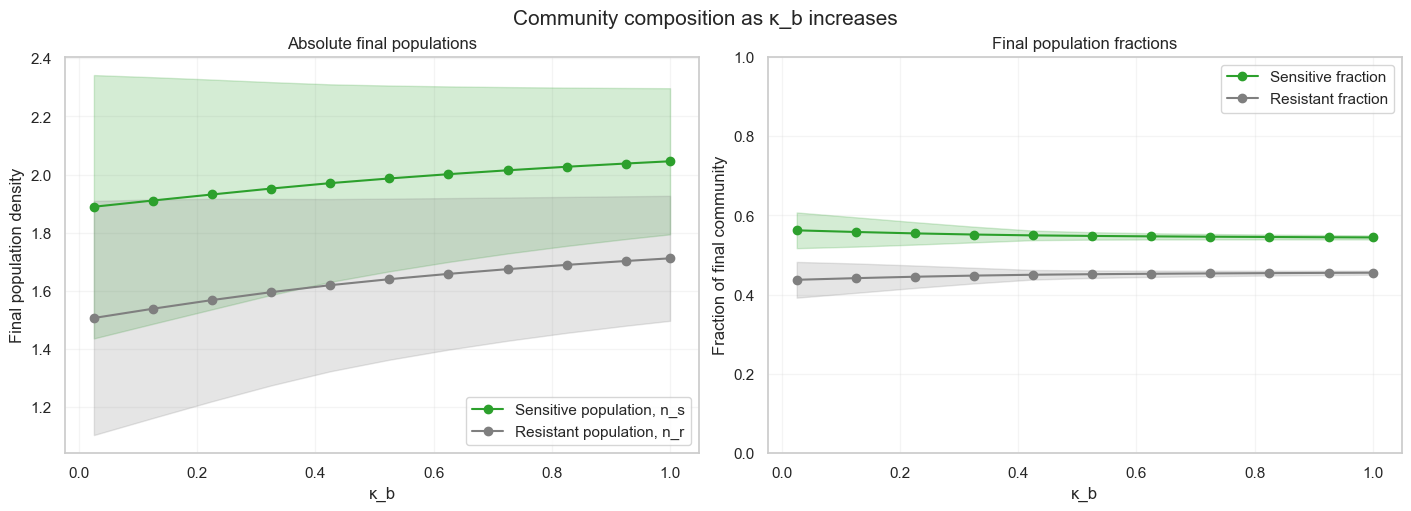

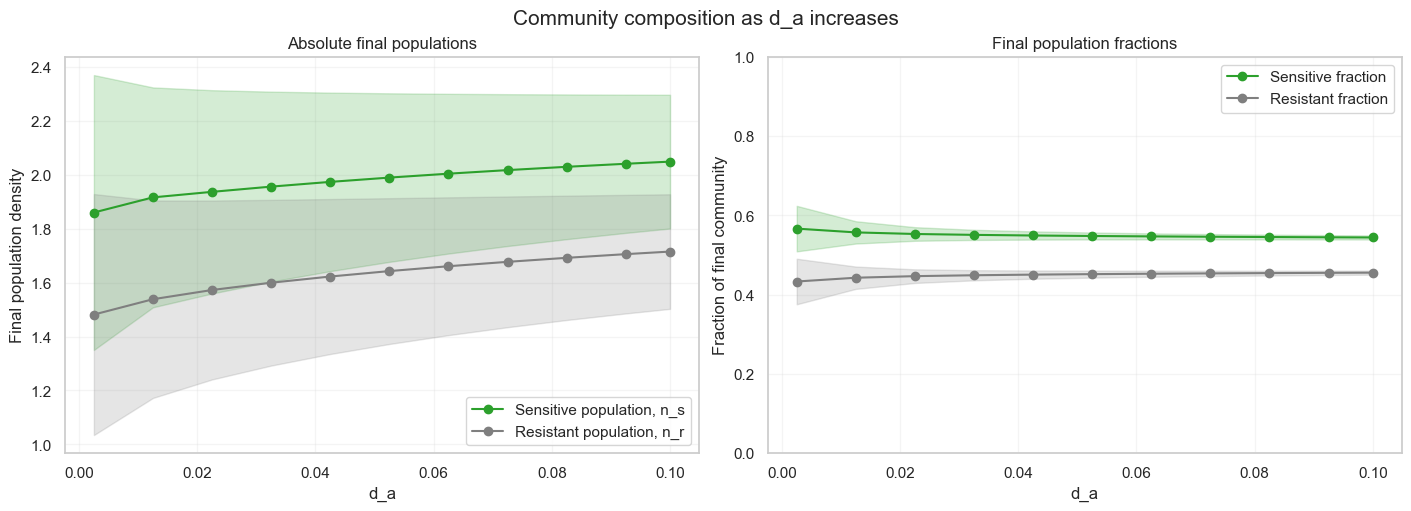

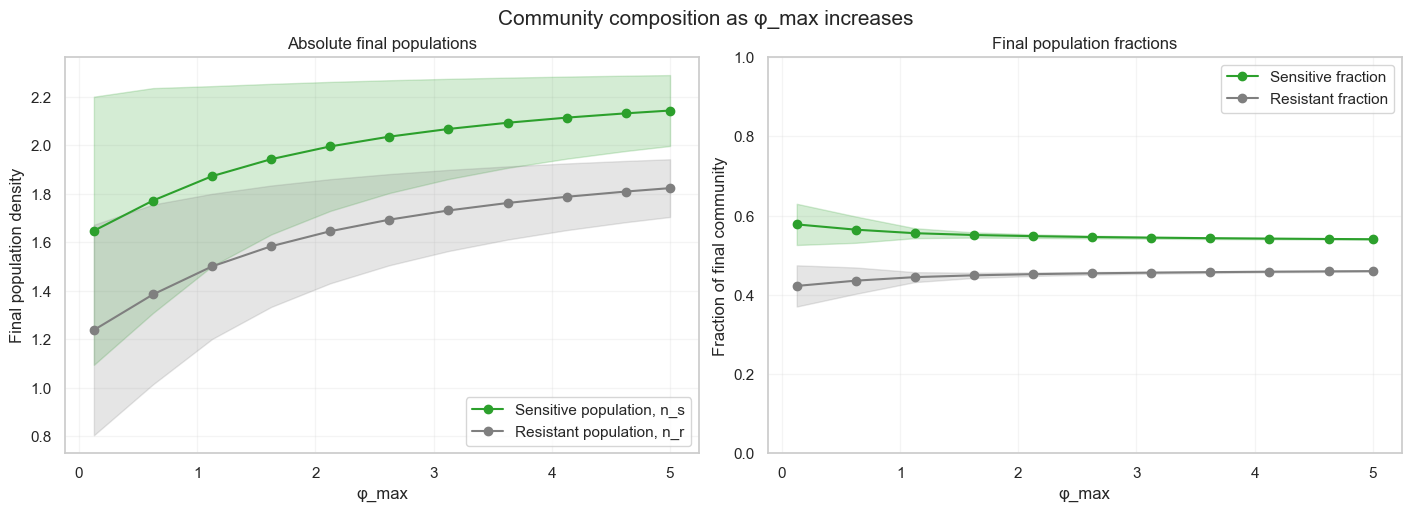

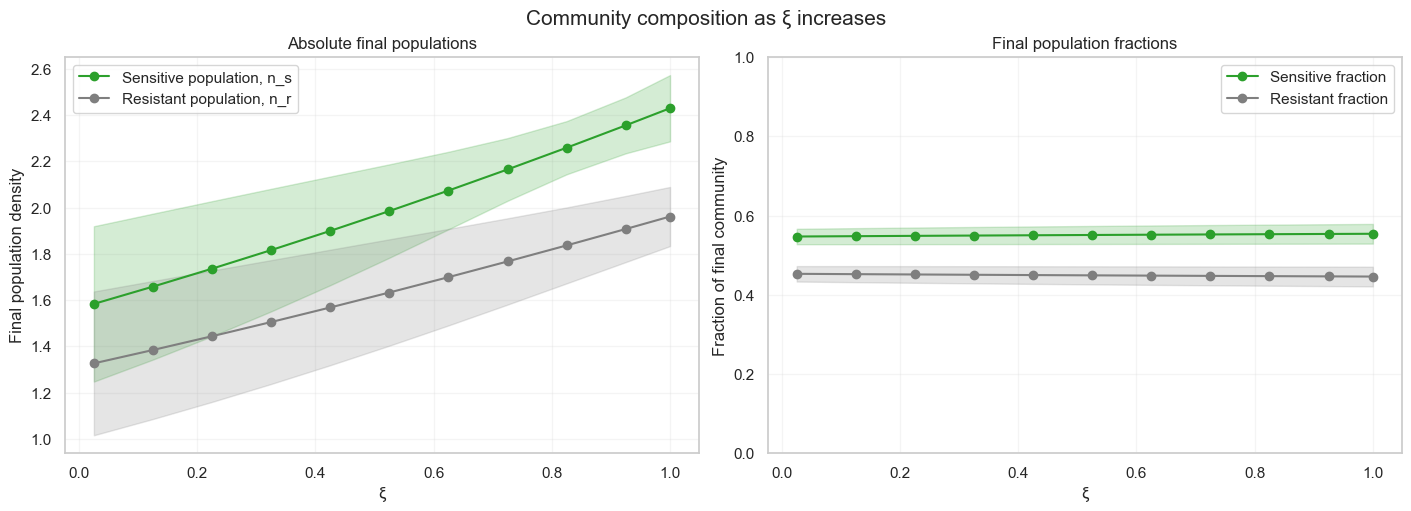

In [10]:
for parameter in PARAMS:
    plot_population_composition_vs_parameter(parameter)
    plt.show()

**Description:**  
This figure shows how the final sensitive and resistant populations change as each parameter increases. The left panels show absolute final population densities, while the right panels show the fraction of the final community made up by each population. The lines represent mean values across simulations, and the shaded regions show variability from the other parameters.

**Interpretation:**  
Increasing κ_b, d_a, and φ_max increases the final absolute sizes of both sensitive and resistant populations. The effect is strongest for φ_max, which produces the largest increase in final population size. These parameters cause only small changes in community composition: the sensitive fraction decreases slightly while the resistant fraction increases slightly. Increasing ξ produces a strong, nearly linear increase in both final populations but leaves their relative fractions almost unchanged. This suggests that nutrient recycling mainly increases overall population recovery without substantially changing the sensitive-to-resistant balance.

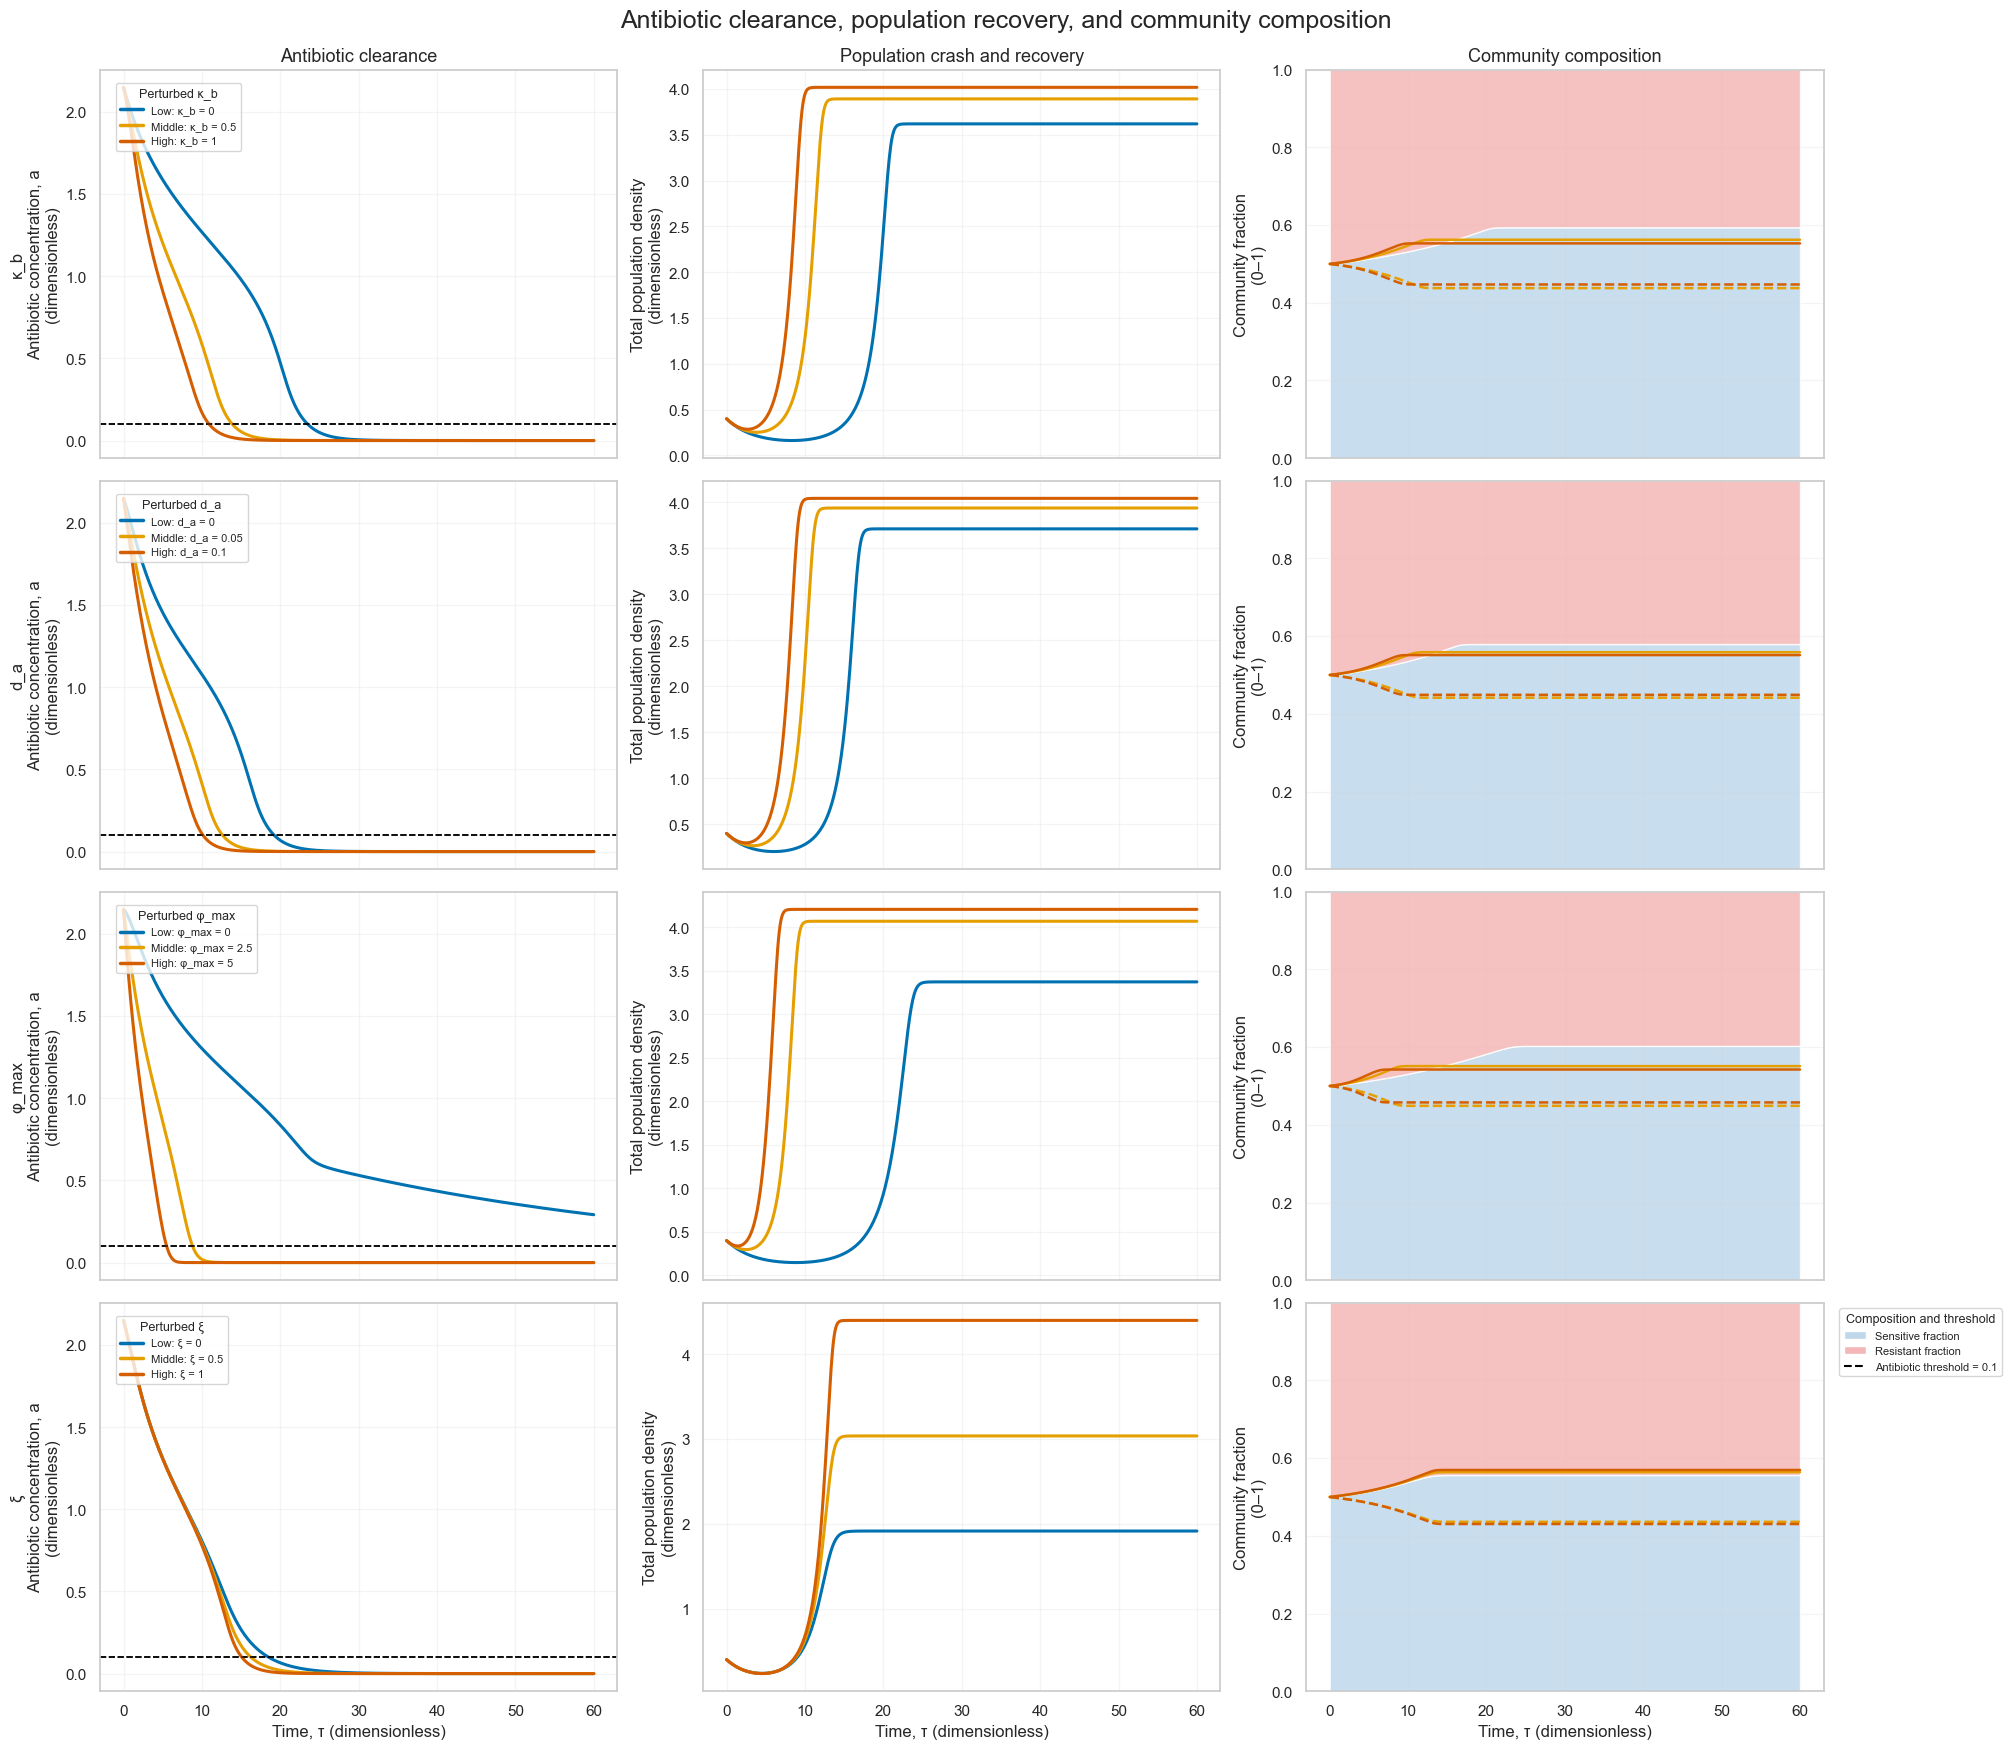

In [14]:
clearance_summary = clearance_recovery_plot(
    t_end=60,
    antibiotic_threshold=0.1
)

**Description:**  
This figure shows how changing κ_b, d_a, φ_max, and ξ affects antibiotic clearance, total population recovery, and community composition over time. Each row represents one parameter, with low, middle, and high values shown by different curves. The left column shows antibiotic concentration, the middle shows total population density, and the right shows the sensitive and resistant fractions of the community.

**Interpretation:**  
Increasing κ_b, d_a, and φ_max accelerates antibiotic clearance and allows the total population to recover earlier. The effect is strongest for φ_max: low φ_max leaves substantial antibiotic in the system and produces the slowest and weakest recovery, while high φ_max leads to rapid clearance and strong regrowth. Changing ξ has little effect on antibiotic clearance or the timing of the initial crash, but it strongly affects the final population size. Higher ξ produces greater post-treatment regrowth while leaving the final community composition relatively similar. Overall, κ_b, d_a, and φ_max mainly control antibiotic persistence and recovery timing, whereas ξ mainly controls the magnitude of population recovery.

In [15]:
def analyze_recovery_regimes(
    extinction_threshold=1e-6,
    dominance_threshold=0.75,
    n_bins=10
):
    """
    Purpose:
        Classify each simulation according to whether the community
        recovered, became sensitive-dominated, became resistant-dominated,
        was wiped out, or failed to converge. The function then summarizes
        which parameter ranges are associated with each outcome.

    Inputs:
        extinction_threshold : float, optional
            Total final population below this value is classified as
            community extinction. Default is 1e-6.

        dominance_threshold : float, optional
            Final population fraction required to classify one population as
            dominant. Default is 0.75.

        n_bins : int, optional
            Number of parameter bins used to summarize regime frequencies.
            Default is 10.

    Outputs:
        regime_df : pandas.DataFrame
            Original dataframe with derived quantities and regime labels.

        regime_summary : pandas.DataFrame
            Fraction of simulations in each biological regime for every
            parameter bin.

        fig : matplotlib.figure.Figure
            Figure showing regime frequencies, final diversity, and final
            total population across parameter ranges.

    Notes:
        Regime priority is:
        1. Community wiped out
        2. Nonconverged near extinction
        3. Nonconverged with substantial population
        4. Sensitive-dominated
        5. Resistant-dominated
        6. Mixed community
    """

    regime_df = df.copy()  # Copy the dataframe so the original data are not modified.

    regime_df["total_final"] = regime_df["ns_final"] + regime_df["nr_final"]  # Calculate the final total population.

    regime_df["sensitive_fraction_final"] = regime_df["ns_final"] / regime_df["total_final"].replace(0, np.nan)  # Calculate the final sensitive fraction.

    regime_df["resistant_fraction_final"] = regime_df["nr_final"] / regime_df["total_final"].replace(0, np.nan)  # Calculate the final resistant fraction.

    regime_df["diversity_final"] = regime_df["diversity_final"].fillna(0)  # Replace undefined diversity values with zero.

    regime_df["community_extinct"] = regime_df["total_final"] < extinction_threshold  # Identify simulations where the whole community is effectively absent.

    regime_df["nonconverged"] = ~regime_df["ss_converged"]  # Identify simulations that did not meet the steady-state criterion.

    regime_df["near_extinction_nonconvergence"] = regime_df["nonconverged"] & (regime_df["total_final"] < extinction_threshold)  # Identify nonconverged simulations near extinction.

    regime_df["substantial_population_nonconvergence"] = regime_df["nonconverged"] & (regime_df["total_final"] >= extinction_threshold)  # Identify nonconverged simulations with substantial remaining population.

    regime_df["regime"] = np.select(
        [
            regime_df["community_extinct"],
            regime_df["near_extinction_nonconvergence"],
            regime_df["substantial_population_nonconvergence"],
            regime_df["sensitive_fraction_final"] >= dominance_threshold,
            regime_df["resistant_fraction_final"] >= dominance_threshold
        ],
        [
            "Community wiped out",
            "Nonconverged near extinction",
            "Nonconverged with population",
            "Sensitive-dominated",
            "Resistant-dominated"
        ],
        default="Mixed community"
    )  # Assign each simulation to one biological regime.

    regime_order = [
        "Community wiped out",
        "Nonconverged near extinction",
        "Nonconverged with population",
        "Sensitive-dominated",
        "Resistant-dominated",
        "Mixed community"
    ]  # Define a consistent regime order.

    summary_rows = []  # Store parameter-bin summaries.

    for parameter in PARAMS:  # Analyze each parameter separately.

        temp = regime_df[[parameter, "regime"]].copy()  # Keep the current parameter and regime.

        temp["parameter_bin"] = pd.qcut(temp[parameter], q=n_bins, duplicates="drop")  # Divide the parameter into quantile bins.

        counts = pd.crosstab(temp["parameter_bin"], temp["regime"], normalize="index")  # Calculate the fraction of each regime within each parameter bin.

        for parameter_bin, row in counts.iterrows():  # Store one row for each parameter bin.

            for regime in regime_order:  # Include every regime even if absent from a bin.

                summary_rows.append({
                    "parameter": parameter,
                    "parameter_bin": str(parameter_bin),
                    "regime": regime,
                    "fraction": row.get(regime, 0)
                })  # Save the regime fraction.

    regime_summary = pd.DataFrame(summary_rows)  # Convert regime summaries to a dataframe.

    regime_colors = {
        "Community wiped out": "#000000",
        "Nonconverged near extinction": "#8C2D04",
        "Nonconverged with population": "#D95F02",
        "Sensitive-dominated": "#56B4E9",
        "Resistant-dominated": "#E69F00",
        "Mixed community": "#999999"
    }  # Define colors for biological regimes.

    fig, axes = plt.subplots(len(PARAMS), 3, figsize=(20, 17), constrained_layout=True)  # Create one row per parameter.

    for row, parameter in enumerate(PARAMS):  # Plot results for each parameter.

        parameter_summary = regime_summary[regime_summary["parameter"] == parameter].copy()  # Select summaries for the current parameter.

        regime_table = parameter_summary.pivot(index="parameter_bin", columns="regime", values="fraction").fillna(0)  # Arrange regime fractions for plotting.

        regime_table = regime_table.reindex(columns=regime_order, fill_value=0)  # Ensure all regimes appear in the same order.

        x = np.arange(len(regime_table))  # Create x positions for the parameter bins.

        bottom = np.zeros(len(regime_table))  # Initialize the bottom of the stacked bars.

        for regime in regime_order:  # Add one stacked layer for each regime.

            axes[row, 0].bar(x, regime_table[regime], bottom=bottom, color=regime_colors[regime], label=regime)  # Plot the fraction of each regime.

            bottom += regime_table[regime].to_numpy()  # Update the stacked-bar baseline.

        axes[row, 0].set_ylim(0, 1)  # Set regime fractions between zero and one.

        axes[row, 0].set_ylabel(f"{LABELS[parameter]}\\nRegime fraction")  # Label the regime-frequency axis.

        axes[row, 0].set_title("Biological outcome regimes")  # Add the regime plot title.

        axes[row, 0].set_xticks(x)  # Set bin positions.

        axes[row, 0].set_xticklabels(np.arange(1, len(x) + 1))  # Label bins in order.

        axes[row, 0].set_xlabel("Parameter bin from low to high")  # Label the parameter-bin axis.

        axes[row, 0].grid(axis="y", alpha=0.2)  # Add horizontal gridlines.

        parameter_values = regime_df.groupby(pd.qcut(regime_df[parameter], q=n_bins, duplicates="drop"), observed=True)[parameter].mean().to_numpy()  # Calculate the mean parameter value in each bin.

        diversity_values = regime_df.groupby(pd.qcut(regime_df[parameter], q=n_bins, duplicates="drop"), observed=True)["diversity_final"].mean().to_numpy()  # Calculate mean diversity in each bin.

        total_values = regime_df.groupby(pd.qcut(regime_df[parameter], q=n_bins, duplicates="drop"), observed=True)["total_final"].mean().to_numpy()  # Calculate mean final total population in each bin.

        axes[row, 1].plot(parameter_values, diversity_values, marker="o", color="#6A3D9A")  # Plot mean diversity across parameter values.

        axes[row, 1].set_xlabel(LABELS[parameter])  # Label the parameter axis.

        axes[row, 1].set_ylabel("Final Shannon diversity")  # Label the diversity axis.

        axes[row, 1].set_title("Community diversity")  # Add the diversity plot title.

        axes[row, 1].grid(alpha=0.2)  # Add a light grid.

        axes[row, 2].plot(parameter_values, total_values, marker="o", color="#0072B2")  # Plot mean final population across parameter values.

        axes[row, 2].set_xlabel(LABELS[parameter])  # Label the parameter axis.

        axes[row, 2].set_ylabel("Final total population")  # Label the final-population axis.

        axes[row, 2].set_title("Community recovery")  # Add the recovery plot title.

        axes[row, 2].grid(alpha=0.2)  # Add a light grid.

    axes[0, 0].legend(title="Outcome regime", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)  # Add one shared regime legend.

    fig.suptitle("Crash, recovery, dominance, extinction, and nonconvergence across parameter ranges", fontsize=18)  # Add the overall figure title.

    plt.show()  # Display the figure.

    return regime_df, regime_summary, fig  # Return classified simulations, summaries, and the figure.

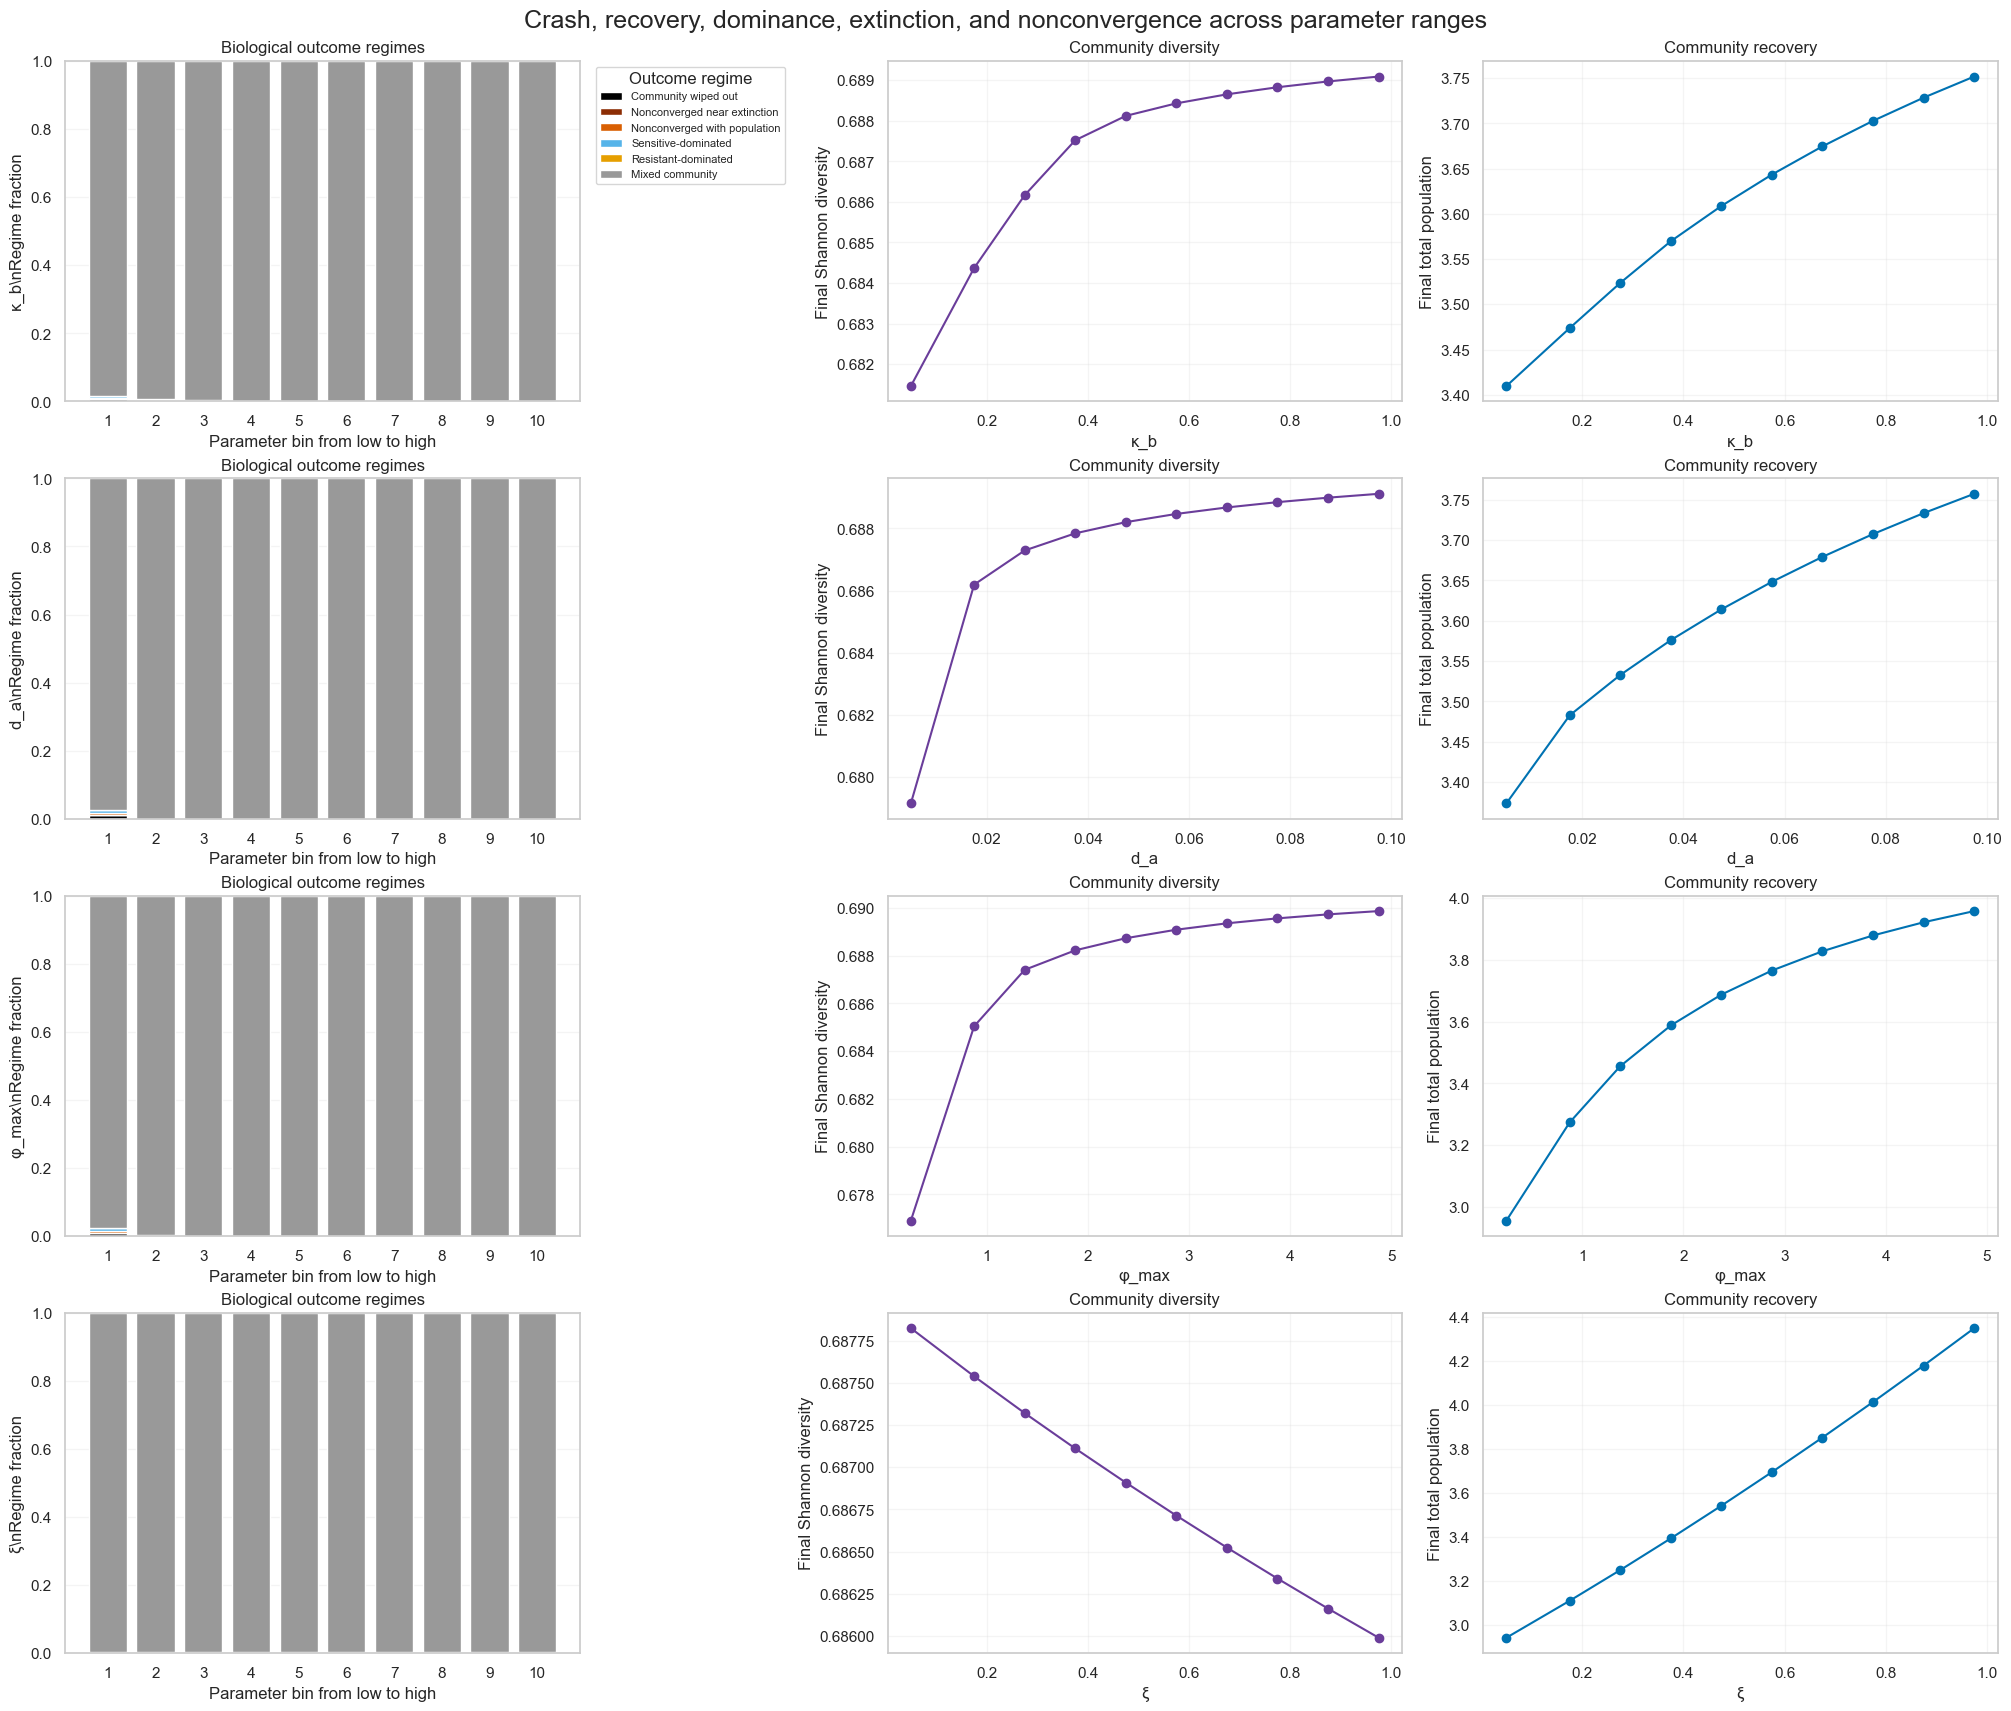

In [16]:
regime_df, regime_summary, regime_fig = analyze_recovery_regimes()

In [17]:
regime_df.groupby("regime")[PARAMS + ["total_final", "diversity_final", "t_steady_state", "peak_loss_total"]].mean()

,kappa_b,d_a,phi_max,xi,total_final,diversity_final,t_steady_state,peak_loss_total
regime,,,,,,,,
Community wiped out,0.086170,0.000000,0.218085,0.514362,4.346175e-08,0.458374,150.000000,1.000000
Mixed community,0.501473,0.050175,2.508441,0.499911,3.609206e+00,0.687785,11.250483,0.245692
Nonconverged with population,0.104167,0.002333,0.241667,0.477500,5.370231e-01,0.362160,150.000000,0.995707
Sensitive-dominated,0.114427,0.005415,0.185771,0.567787,2.115402e+00,0.487559,101.242614,0.971183


KeyError: 'Column not found: kappa_b'

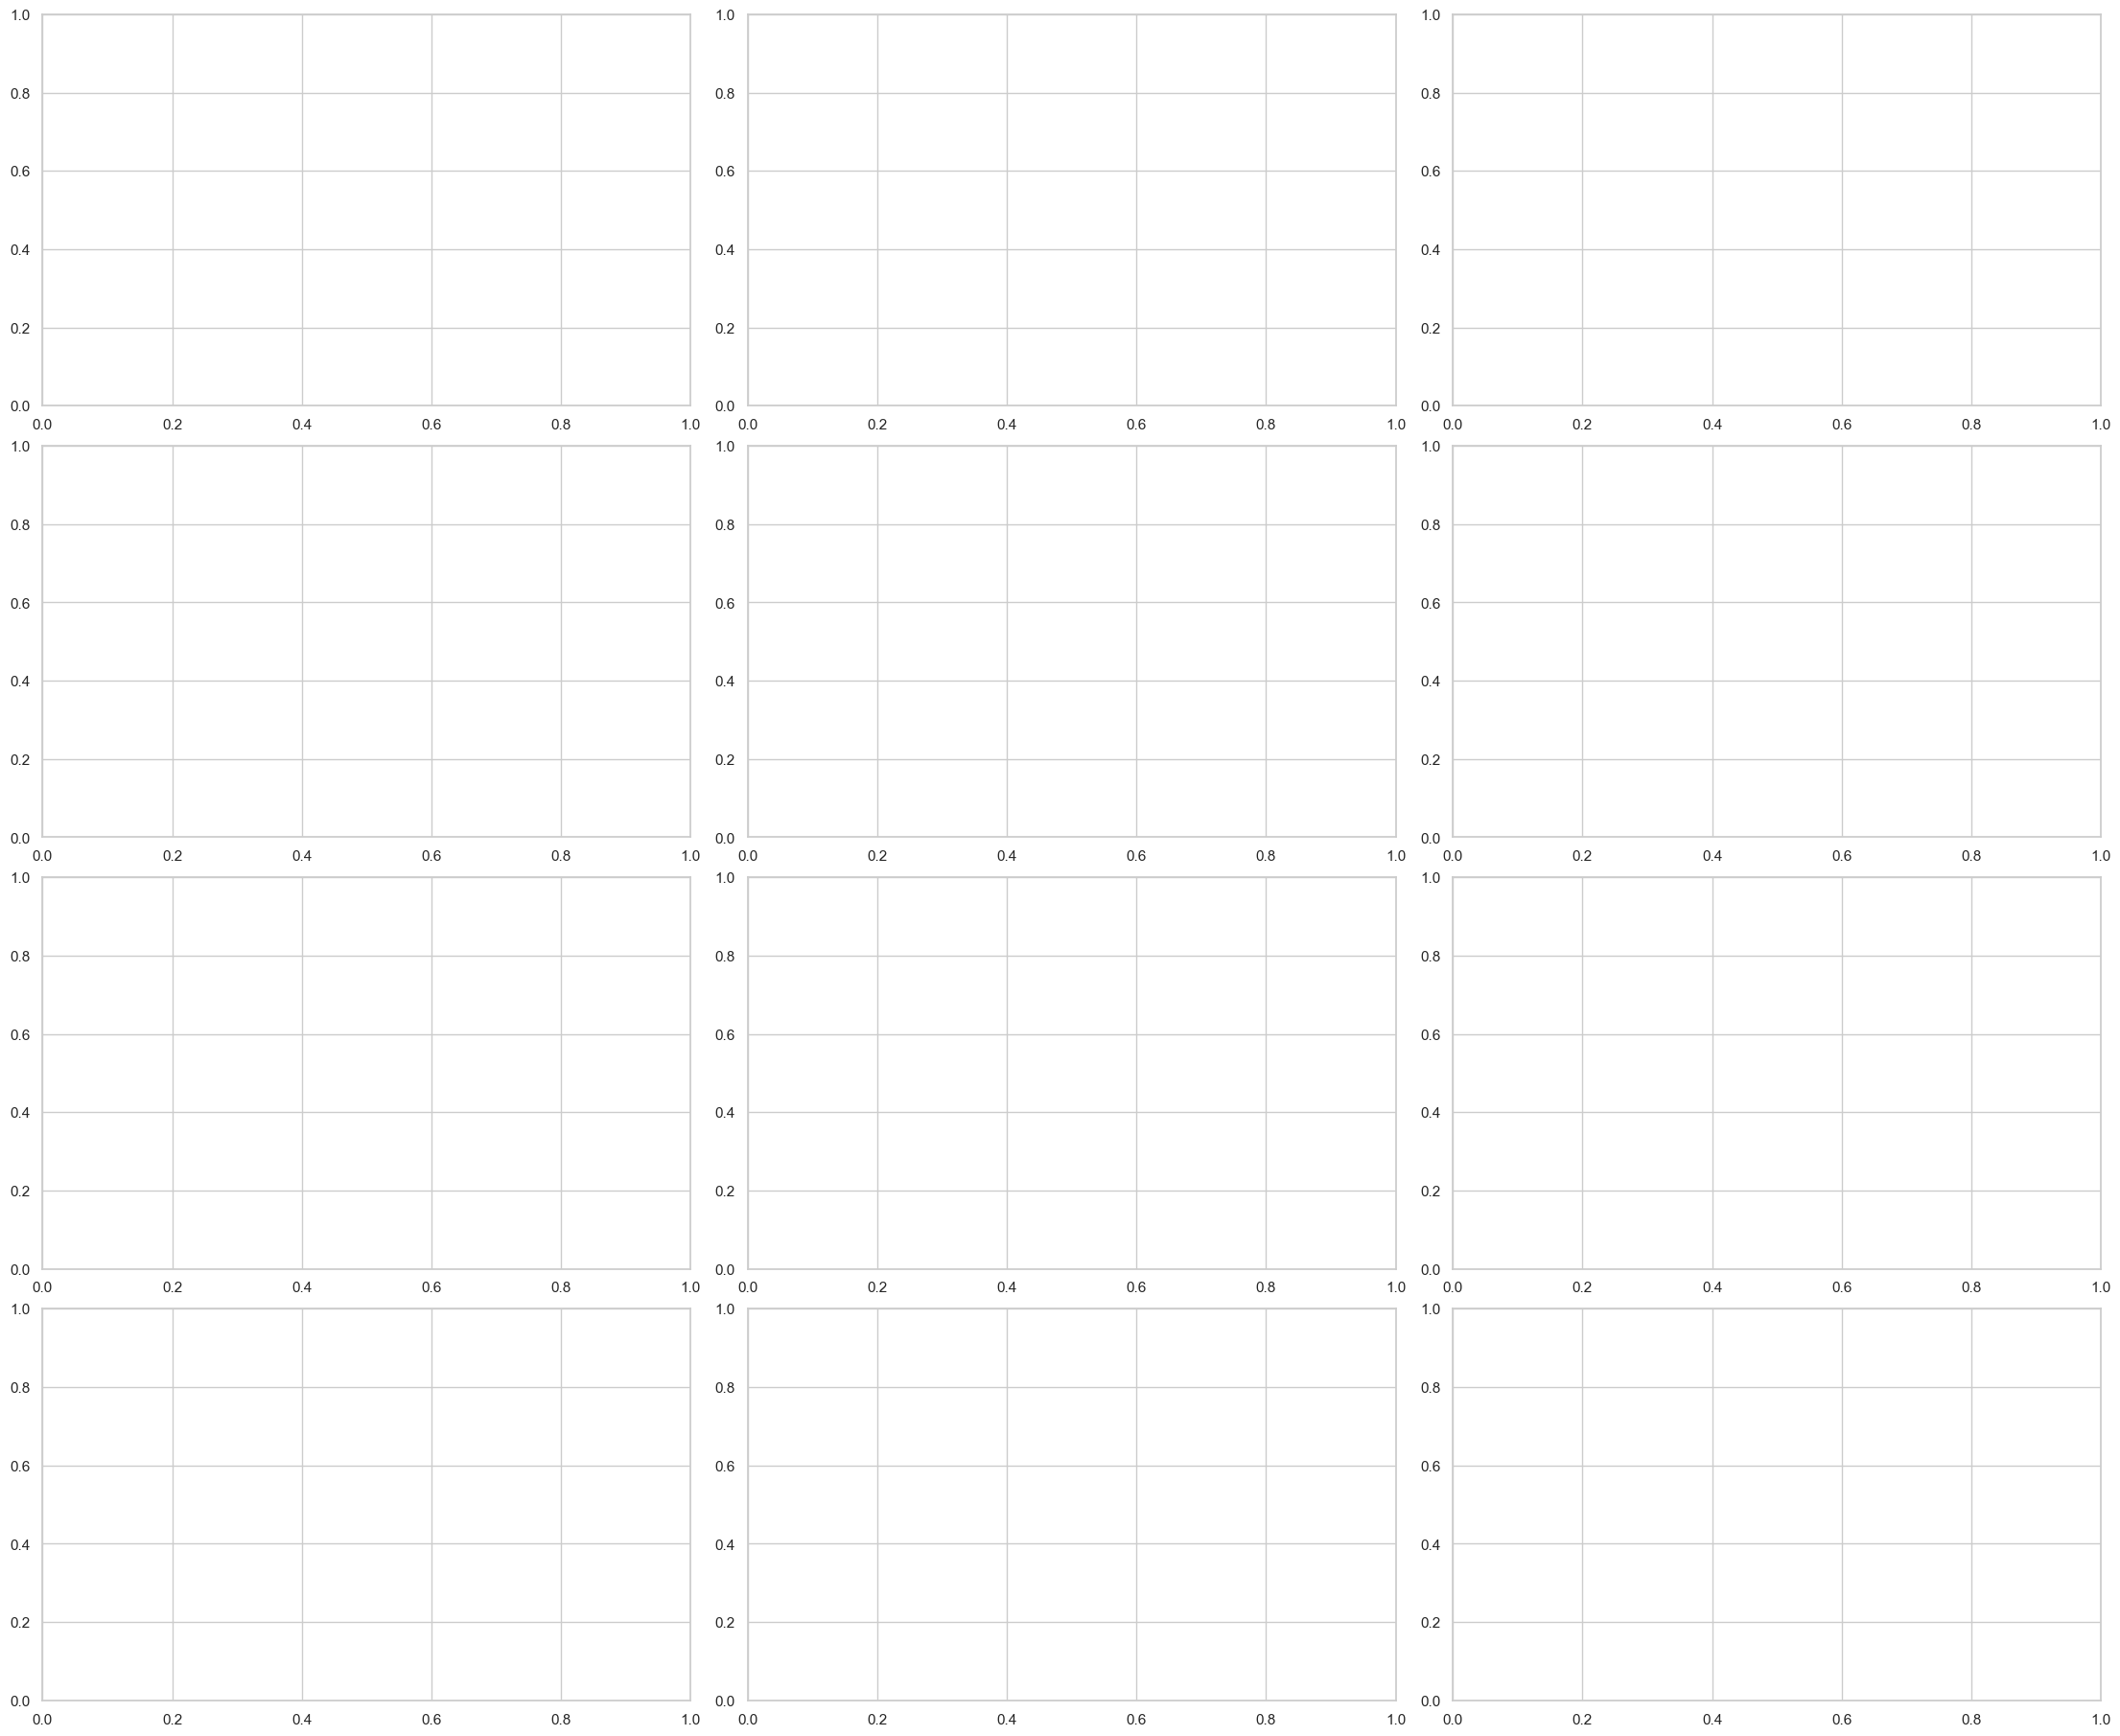

In [18]:
def analyze_recovery_regimes(extinction_threshold=1e-6, dominance_threshold=0.75, n_bins=10):
    """
    Purpose:
        Classify simulations according to community extinction, nonconvergence,
        sensitive dominance, resistant dominance, or mixed community behavior.
        The function summarizes how these regimes change across parameter ranges.

    Inputs:
        extinction_threshold : float, optional
            Total final population below this value is classified as extinction.
            Default is 1e-6.

        dominance_threshold : float, optional
            Final population fraction required to classify one population as
            dominant. Default is 0.75.

        n_bins : int, optional
            Number of parameter bins used in the bar plots. Default is 10.

    Outputs:
        regime_df : pandas.DataFrame
            Simulation dataframe with derived quantities and regime labels.

        regime_summary : pandas.DataFrame
            Fraction of simulations in each regime for each parameter bin.

        fig : matplotlib.figure.Figure
            Figure containing regime, diversity, and recovery plots.
    """

    regime_df = df.copy()  # Copy the dataframe so the original is not modified.

    regime_df["total_final"] = regime_df["ns_final"] + regime_df["nr_final"]  # Calculate final total population.

    regime_df["sensitive_fraction_final"] = regime_df["ns_final"] / regime_df["total_final"].replace(0, np.nan)  # Calculate final sensitive fraction.

    regime_df["resistant_fraction_final"] = regime_df["nr_final"] / regime_df["total_final"].replace(0, np.nan)  # Calculate final resistant fraction.

    regime_df["nonconverged"] = ~regime_df["ss_converged"]  # Identify simulations that did not converge.

    regime_df["community_extinct"] = regime_df["total_final"] < extinction_threshold  # Identify simulations where the whole community was effectively wiped out.

    regime_df["near_extinction_nonconvergence"] = regime_df["nonconverged"] & regime_df["community_extinct"]  # Identify nonconverged simulations near extinction.

    regime_df["substantial_population_nonconvergence"] = regime_df["nonconverged"] & ~regime_df["community_extinct"]  # Identify nonconverged simulations with substantial population remaining.

    regime_df["regime"] = np.select([regime_df["community_extinct"], regime_df["near_extinction_nonconvergence"], regime_df["substantial_population_nonconvergence"], regime_df["sensitive_fraction_final"] >= dominance_threshold, regime_df["resistant_fraction_final"] >= dominance_threshold], ["Community wiped out", "Nonconverged near extinction", "Nonconverged with population", "Sensitive-dominated", "Resistant-dominated"], default="Mixed community")  # Assign each simulation to a biological regime.

    regime_order = ["Community wiped out", "Nonconverged near extinction", "Nonconverged with population", "Sensitive-dominated", "Resistant-dominated", "Mixed community"]  # Define a consistent regime order.

    regime_colors = {"Community wiped out": "#000000", "Nonconverged near extinction": "#8C2D04", "Nonconverged with population": "#D95F02", "Sensitive-dominated": "#56B4E9", "Resistant-dominated": "#E69F00", "Mixed community": "#999999"}  # Define regime colors.

    summary_rows = []  # Store parameter-bin summaries.

    for parameter in PARAMS:  # Analyze each parameter separately.

        temp = regime_df[[parameter, "regime"]].copy()  # Keep the current parameter and regime.

        temp["parameter_bin"] = pd.qcut(temp[parameter], q=n_bins, duplicates="drop")  # Divide the parameter into quantile-based bins.

        counts = pd.crosstab(temp["parameter_bin"], temp["regime"], normalize="index")  # Calculate regime fractions within each parameter bin.

        parameter_values = temp.groupby("parameter_bin", observed=True)[parameter].mean().to_numpy()  # Calculate the mean parameter value in each bin.

        for parameter_bin, row in counts.iterrows():  # Loop through each parameter bin.

            for regime in regime_order:  # Include every regime in every bin.

                summary_rows.append({"parameter": parameter, "parameter_bin": str(parameter_bin), "parameter_value": parameter_values[len(summary_rows) % len(parameter_values)], "regime": regime, "fraction": row.get(regime, 0)})  # Store the regime fraction and parameter value.

    regime_summary = pd.DataFrame(summary_rows)  # Convert summaries into a dataframe.

    fig, axes = plt.subplots(len(PARAMS), 3, figsize=(22, 18), constrained_layout=True)  # Create one row per parameter.

    for row, parameter in enumerate(PARAMS):  # Plot results for each parameter.

        parameter_summary = regime_summary[regime_summary["parameter"] == parameter].copy()  # Select summaries for the current parameter.

        regime_table = parameter_summary.pivot(index="parameter_bin", columns="regime", values="fraction").fillna(0)  # Arrange regime fractions for plotting.

        regime_table = regime_table.reindex(columns=regime_order, fill_value=0)  # Keep regime order consistent.

        parameter_values = temp.groupby("parameter_bin", observed=True)[parameter].mean().to_numpy() if parameter == PARAMS[0] else regime_df.groupby(pd.qcut(regime_df[parameter], q=n_bins, duplicates="drop"), observed=True)[parameter].mean().to_numpy()  # Calculate parameter values for x-axis labels.

        x = np.arange(len(regime_table))  # Create bar positions.

        bottom = np.zeros(len(regime_table))  # Initialize the stacked-bar baseline.

        for regime in regime_order:  # Add each regime as a stacked bar layer.

            axes[row, 0].bar(x, regime_table[regime], bottom=bottom, color=regime_colors[regime], label=regime)  # Plot regime fractions.

            bottom += regime_table[regime].to_numpy()  # Update the stacked-bar baseline.

        if parameter == "d_a":  # Use more decimal places for the smaller d_a range.

            tick_labels = [f"{value:.3f}" for value in parameter_values]

        elif parameter_values.max() <= 1:  # Use one decimal place for parameters ranging from zero to one.

            tick_labels = [f"{value:.1f}" for value in parameter_values]

        else:  # Use one decimal place for larger parameter ranges.

            tick_labels = [f"{value:.1f}" for value in parameter_values]

        axes[row, 0].set_xticks(x)  # Set bar positions.

        axes[row, 0].set_xticklabels(tick_labels, rotation=45, ha="right")  # Label bars with actual parameter values.

        axes[row, 0].set_ylim(0, 1)  # Set regime fractions between zero and one.

        axes[row, 0].set_xlabel(f"{LABELS[parameter]} value")  # Label the parameter axis.

        axes[row, 0].set_ylabel("Regime fraction")  # Label the regime-fraction axis.

        axes[row, 0].set_title("Biological outcome regimes")  # Add the regime plot title.

        axes[row, 0].grid(axis="y", alpha=0.2)  # Add horizontal gridlines.

        diversity_summary = regime_df.groupby(pd.qcut(regime_df[parameter], q=n_bins, duplicates="drop"), observed=True).agg(parameter_value=(parameter, "mean"), diversity=("diversity_final", "mean")).reset_index()  # Calculate mean diversity within each parameter bin.

        population_summary = regime_df.groupby(pd.qcut(regime_df[parameter], q=n_bins, duplicates="drop"), observed=True).agg(parameter_value=(parameter, "mean"), total_population=("total_final", "mean")).reset_index()  # Calculate mean final population within each parameter bin.

        axes[row, 1].plot(diversity_summary["parameter_value"], diversity_summary["diversity"], marker="o", color="#6A3D9A")  # Plot mean diversity.

        axes[row, 1].set_xlabel(LABELS[parameter])  # Label the diversity x-axis.

        axes[row, 1].set_ylabel("Final Shannon diversity")  # Label the diversity y-axis.

        axes[row, 1].set_title("Community diversity")  # Add the diversity title.

        axes[row, 1].grid(alpha=0.2)  # Add a light grid.

        axes[row, 2].plot(population_summary["parameter_value"], population_summary["total_population"], marker="o", color="#0072B2")  # Plot mean final population.

        axes[row, 2].set_xlabel(LABELS[parameter])  # Label the recovery x-axis.

        axes[row, 2].set_ylabel("Final total population")  # Label the recovery y-axis.

        axes[row, 2].set_title("Community recovery")  # Add the recovery title.

        axes[row, 2].grid(alpha=0.2)  # Add a light grid.

    axes[0, 0].legend(title="Outcome regime", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)  # Add the shared regime legend.

    fig.suptitle("Crash, recovery, dominance, extinction, and nonconvergence across parameter ranges", fontsize=18)  # Add the overall title.

    plt.show()  # Display the figure.

    return regime_df, regime_summary, fig  # Return the classified dataframe, summary dataframe, and figure.


regime_df, regime_summary, regime_fig = analyze_recovery_regimes()  # Run the function and generate the figure.